### 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options).

* Book version of this notebook - https://www.learnpytorch.io/02_pytorch_classification/

* All other resources - https://github.com/mrdbourke/pytorch-deep-learning

* Stuck? Ask a question - https://github.com/mrdbourke/pytorch-deep-learning/discussions

### 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [5]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [6]:
circles.label.value_counts()

,count
label,
1,500
0,500


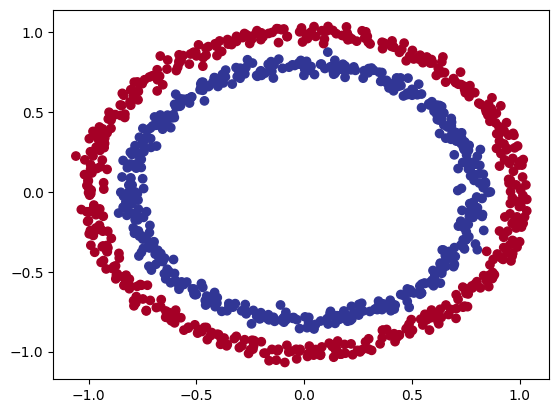

In [7]:
# Visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

`Note:` The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 Check input and output shapes

### 1.2 Turn data into tensors and create train and test splits

In [8]:
import torch

In [9]:
torch.__version__

'2.9.0+cu126'

In [10]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [11]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [12]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [13]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 0.2 = 20%  of data will be test & 80% will be train
                                                    random_state=42)

In [14]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [15]:
n_samples

1000

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [16]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we've setup device agnostic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target `device`

In [18]:
X_train.shape

torch.Size([800, 2])

In [19]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [20]:
from sklearn import datasets
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and outputs a single feature (same shape as y)

  # 3. Define a forward() method that outlines the forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x -> layer_1 ->  layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
device

'cuda'

In [22]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [23]:
# Let's replicate the model above using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0798,  0.0249],
                      [ 0.5202,  0.0148],
                      [-0.2656,  0.1542],
                      [-0.5966, -0.5985],
                      [-0.6179, -0.5906]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3477,  0.5359, -0.4160,  0.4424,  0.4302], device='cuda:0')),
             ('1.weight',
              tensor([[-0.0338,  0.0242,  0.4162,  0.3809, -0.1245]], device='cuda:0')),
             ('1.bias', tensor([-0.3854], device='cuda:0'))])

In [25]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.],
        [-1.],
        [-0.],
        [-0.],
        [-0.],
        [-1.],
        [-1.],
        [-1.],
        [-0.],
        [-1.]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might want MAE or MSE (mean absolute error or mean squared error).

For classification you might want binary cross entropy or categorical cross entropy (cross entropy).

As a reminder, the loss function measures how *wrong* your models predictions are.

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

* For some common choices of loss functions and optimizers - https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-function-and-optimizer
* For the loss function we're going to use `torch.nn.BECWithLogitsLoss()`, for more on what binary cross entropy (BCE) is, check out this article - https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a
* For a defintion on what a logit is in deep learning - https://stackoverflow.com/a/52111173/7900723
* For different optimizers see `torch.optim`

In [27]:
nn.L1Loss()

L1Loss()

In [28]:
# Setup the loss function
# loss_fn=nn.BCEWLoss() # BCELoss=requires input to have gone through the sigmoid activation function prior to input t0 BCELoss

loss_fn=nn.BCEWithLogitsLoss() # BCEWithLogistisLoss=sigmoid active function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr=0.1)

In [29]:
# Calculate accuracy - out of 100 example , what percentage does our model get right ?
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc= (correct/len(y_pred))*100
  return acc

## Traing model

To train or model, we're going to need to build a training loop:

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward(propagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into prediction probabilities by passing them to some kind of activation function ( e.g. sigmoid for binary classification adn softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the `argmax()`.

In [30]:
# View rhe forst 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits =model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.3866],
        [-0.5098],
        [-0.2139],
        [-0.4349],
        [-0.4523]], device='cuda:0')

In [31]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [32]:
# Use the sigmoid activation function on our model logits to turn them into prediction probablitis.
y_pred_prob=torch.sigmoid(y_logits)
y_pred_prob

tensor([[0.4045],
        [0.3752],
        [0.4467],
        [0.3930],
        [0.3888]], device='cuda:0')

For our prediction probability values,we nee to perform a range-style rounding on them:
* `y_pred_prob` >=0.5, `y=1` (class 1)
* `y_pred_prob` < 0.5, `y=1` (class 0)

In [33]:
torch.round(y_pred_prob)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

In [34]:
# Find the predicted labels
y_preds=torch.round(y_pred_prob)

# In full (logist -> -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#Checj for equility
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))

#Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [35]:
torch.round(y_pred_prob)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

### 3.2 Building a training and testing loop

In [36]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss/accuracy
  # oss=loss_fn(torch.sigmoid(y_logits)) # nn,BCELoss expects prediction probabillities as input
  loss=loss_fn(y_logits,  # nn.BCEWithoutLogistisLoss expects raw logits as input
              y_train )
  acc=accuracy_fn(y_true=y_train,
                  y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backeard (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    # 2 Calculate test loss/acc
    test_loss=loss_fn(test_logits,
                      y_test)
    test_acc=accuracy_fn(y_true=y_test,
                         y_pred=test_pred)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} |  Loss: {loss:.5f},  Acc: {acc:.2f}%| Test Loss: {test_loss: .5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 |  Loss: 0.71923,  Acc: 50.00%| Test Loss:  0.71237, Test acc: 50.00%
Epoch: 10 |  Loss: 0.70456,  Acc: 48.50%| Test Loss:  0.69891, Test acc: 46.50%
Epoch: 20 |  Loss: 0.69910,  Acc: 45.12%| Test Loss:  0.69417, Test acc: 50.50%
Epoch: 30 |  Loss: 0.69670,  Acc: 46.25%| Test Loss:  0.69246, Test acc: 52.00%
Epoch: 40 |  Loss: 0.69544,  Acc: 47.38%| Test Loss:  0.69189, Test acc: 53.50%
Epoch: 50 |  Loss: 0.69468,  Acc: 46.88%| Test Loss:  0.69178, Test acc: 53.00%
Epoch: 60 |  Loss: 0.69418,  Acc: 47.12%| Test Loss:  0.69189, Test acc: 53.50%
Epoch: 70 |  Loss: 0.69383,  Acc: 47.12%| Test Loss:  0.69209, Test acc: 53.50%
Epoch: 80 |  Loss: 0.69359,  Acc: 47.25%| Test Loss:  0.69232, Test acc: 53.50%
Epoch: 90 |  Loss: 0.69342,  Acc: 46.88%| Test Loss:  0.69256, Test acc: 53.00%


In [37]:
loss_fn

BCEWithLogitsLoss()

In [38]:
loss_fn_without_logits =nn.BCELoss()
loss_fn_without_logits

BCELoss()

## 4.Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some predicctions and make them visual!

in other words, "Visualize, visualize, visualize"

To do so, we're going to import a function called `plot_decision_boundary()`-https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

In [39]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch rep (if it's not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")

else:
  print("Download helper_functions.py")
  request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", 'wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


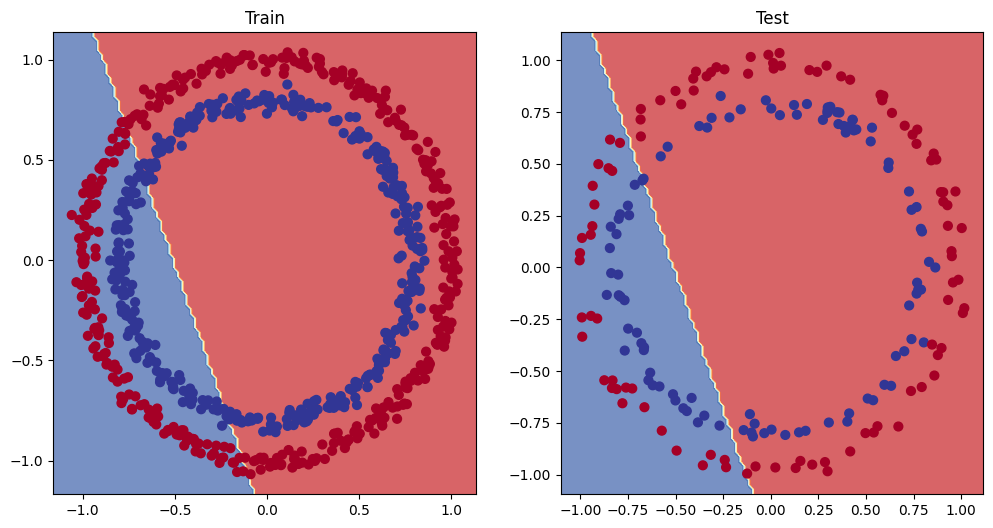

In [40]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

### 5. Improving a model (from a model perspective)


* Add more layers - give the model more chances to learn about patterns in the data

* Add more hidden units - go from 5 hidden units to 10 hidden units

* Fit for longer

* Changing the activation functions

* Change the learning rate

* Change the loss function

These optins are all from a model's prespective because they deal directly with the model, rather than the data.

And because these options are all values we (as machine learning engineers and data scietists ) can change , they are referred as **hyperparameters**

Let's try and improving our model by:
* Adding more hidden units: 5 -> 10
* Increase the number of layers : 2 -> 3
* Increase the number of epochs: 100 -> 1000



In [41]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0689,  0.0157],
                      [ 0.5397,  0.0318],
                      [-0.2162,  0.1929],
                      [-0.5432, -0.5562],
                      [-0.6369, -0.6064]])),
             ('0.bias', tensor([-0.3623,  0.5592, -0.3357,  0.5268,  0.4026])),
             ('1.weight',
              tensor([[-0.0982,  0.2193,  0.3202,  0.3420, -0.1882]])),
             ('1.bias', tensor([-0.1671]))])

In [42]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 =nn.Linear(in_features=2, out_features=10)
    self.layer_2=nn.Linear(in_features=10, out_features=10)
    self.layer_3=nn.Linear(in_features=10, out_features=1)

  def forward(self,x):
    # z=self.layer_1(x)
    # z=self.layer_2(z)
    # z=self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # This eay of writing operation leverages speed ups where possible behind the scenes


model_1=CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [43]:
X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]], device='cuda:0'),
 tensor([1., 0., 0., 0., 1.], device='cuda:0'))

In [44]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [45]:
# Create a loss function
loss_fn =nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer =torch.optim.SGD(params=model_1.parameters(),
                           lr=0.1)


In [46]:
#Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for Longer
epochs =1000

# Put data on the target device
X_train,y_train = X_train.to(device), y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()
  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> prediction

  # 2. Calculate the loss/acc
  loss = loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,
                  y_pred=y_pred)

  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. optimizer step (gradient descent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1.Forward pass
    test_logits=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    # 2. Calculate loss
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc=accuracy_fn(y_true=y_test,
                         y_pred=test_pred)

  # Print out what's happen's
  if epoch %100 ==0:
    print(f"Epoch:{epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch:0 | Loss: 0.69396, Acc: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch:100 | Loss: 0.69305, Acc: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch:200 | Loss: 0.69299, Acc: 51.12% | Test loss: 0.69437, Test acc: 46.00%
Epoch:300 | Loss: 0.69298, Acc: 51.62% | Test loss: 0.69458, Test acc: 45.00%
Epoch:400 | Loss: 0.69298, Acc: 51.12% | Test loss: 0.69465, Test acc: 46.00%
Epoch:500 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69467, Test acc: 46.00%
Epoch:600 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch:700 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch:800 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%
Epoch:900 | Loss: 0.69298, Acc: 51.00% | Test loss: 0.69468, Test acc: 46.00%


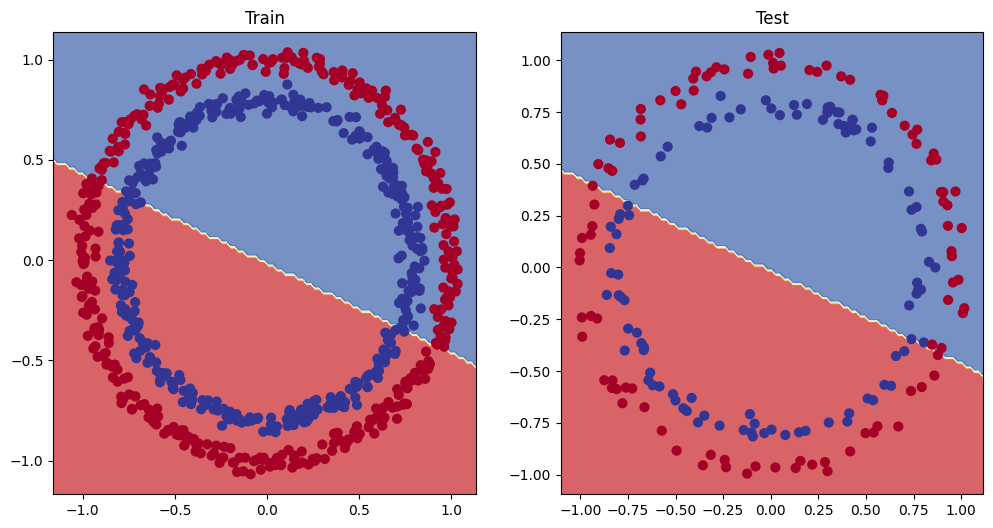

In [47]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way ti troubleshoot to a larger problem is to test out a smaller problem.


In [48]:
# Create some data (same as notebook 01)
weight=0.7
bias = 0.3
start =0
end =1
step = 0.01

# Create data
X_regression = torch.arange(start,end,step).unsqueeze(dim=1)
y_regression =weight * X_regression + bias # Linear regression formula (without epsilon)

# Check the data
print(len(X_regression))

X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [49]:
# Create train and test splits
train_split=int(0.8 * len(X_regression))
X_train_regression , y_train_regression =X_regression[:train_split],y_regression[:train_split]

X_test_regression , y_test_regression =X_regression[train_split:],y_regression[train_split:]

# Check the lengths of each
len(X_train_regression),len(X_test_regression), len(y_train_regression),len(y_test_regression)

(80, 20, 80, 20)

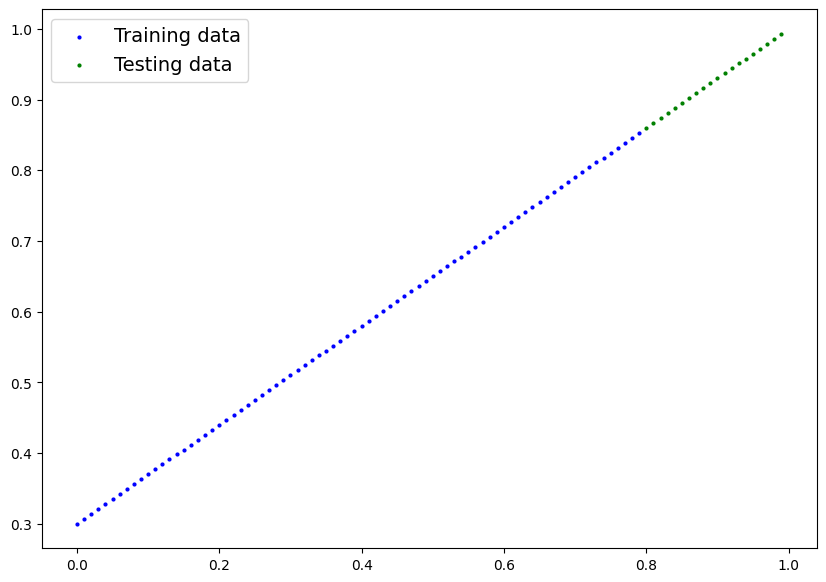

In [50]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data= X_test_regression,
                 test_labels = y_test_regression)

In [51]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting `model_1` to fit a straight line


In [53]:
#Same architecture as model_1 (but using nn.Seqential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [54]:
# Loss and optimizer
loss_fn =nn.L1Loss() # MAE loss with regression data
optimizer =torch.optim.SGD(model_2.parameters(),lr=0.1)

In [55]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs =1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device),y_train_regression.to(device)
X_test_regression, y_test_regression =X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  y_pred= model_2(X_train_regression)
  loss = loss_fn(y_pred,y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss =loss_fn(test_pred,y_test_regression)

  # Print what happening
  if epoch % 100 ==0:
    print(f"Epoch:{epoch} | Loss: {loss:.5f}, Test loss: {test_loss:.5f}")


Epoch:0 | Loss: 0.75986, Test loss: 0.54143
Epoch:100 | Loss: 0.09309, Test loss: 0.02901
Epoch:200 | Loss: 0.07376, Test loss: 0.02850
Epoch:300 | Loss: 0.06745, Test loss: 0.00615
Epoch:400 | Loss: 0.06107, Test loss: 0.02004
Epoch:500 | Loss: 0.05698, Test loss: 0.01061
Epoch:600 | Loss: 0.04857, Test loss: 0.01326
Epoch:700 | Loss: 0.06109, Test loss: 0.02127
Epoch:800 | Loss: 0.05599, Test loss: 0.01426
Epoch:900 | Loss: 0.05571, Test loss: 0.00603


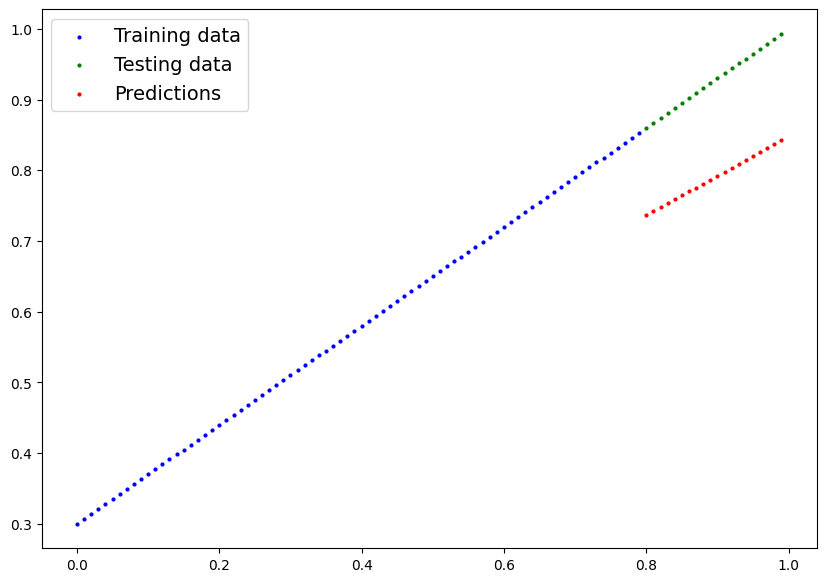

In [57]:
# Turn on evaluation mode
model_2.eval()


# Make predictios (inference)
with torch.inference_mode():
  y_preds= model_2(X_test_regression)

#plot data and predictions
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data= X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                  predictions =y_preds.cpu()
                   );


## 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a strainght and non-straight lines?"

or in machine learning terms, an infinite (but really is finite) of linear and non-linear functions ?

### 6.1 Recreating non-linear data (red and blue circles)

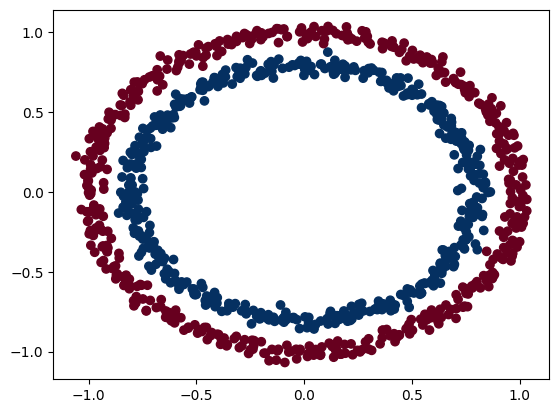

In [58]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples =1000

X,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

plt.scatter(X[:,0], X[:,1],c=y,cmap=plt.cm.RdBu)


In [59]:
# Convert data to tesors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)
X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

* Linear= Straight Linear

* Non-linear = non-straight lines

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear)functions which are potentially able to find patterns in data.


In [60]:
# Building with non-linear activation functions

from torch import  nn
class CircleModelV2(nn.Module):
  def __init__(self) :
    super().__init__()
    self.layer_1=nn.Linear(in_features=2, out_features=10)
    self.layer_2=nn.Linear(in_features=10, out_features=10)
    self.layer_3=nn.Linear(in_features=10, out_features=1)
    self.relu=nn.ReLU() # relu is a non-linear activation functions

  def forward(self,x):
    # Where should we put our non-linear activation functions?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_3=CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [61]:
# Setup loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(model_3.parameters(),
                          lr=0.1)

In [62]:
# Spam or not spam
# Credit cards = fraud or not fraud
# insurance clamims = at fault or not fault

### 6.3 Training a model with non-linearity

In [63]:
len(X_test),len(y_test)

(200, 200)

In [65]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model_3.to(device)

# Move data to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Forward pass
y_logits = model_3(X_train).squeeze()
y_pred = torch.round(torch.sigmoid(y_logits))

In [66]:
for epoch in range(epochs):
  # Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)

  # 3. Accuracy
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # 4. Optimizer zero grad
  optimizer.zero_grad()

  # 5. Backward pass
  loss.backward()

  # 6. Optimizer step
  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))

      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # Print
  if epoch % 100 == 0:
      print(f"Epoch: {epoch} | "
            f"Loss: {loss:.4f}, Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6932, Test Acc: 50.00%
Epoch: 100 | Loss: 0.6912, Acc: 52.88% | Test Loss: 0.6910, Test Acc: 52.50%
Epoch: 200 | Loss: 0.6898, Acc: 53.37% | Test Loss: 0.6894, Test Acc: 55.00%
Epoch: 300 | Loss: 0.6879, Acc: 53.00% | Test Loss: 0.6872, Test Acc: 56.00%
Epoch: 400 | Loss: 0.6852, Acc: 52.75% | Test Loss: 0.6841, Test Acc: 56.50%
Epoch: 500 | Loss: 0.6810, Acc: 52.75% | Test Loss: 0.6794, Test Acc: 56.50%
Epoch: 600 | Loss: 0.6751, Acc: 54.50% | Test Loss: 0.6729, Test Acc: 56.00%
Epoch: 700 | Loss: 0.6666, Acc: 58.38% | Test Loss: 0.6632, Test Acc: 59.00%
Epoch: 800 | Loss: 0.6516, Acc: 64.00% | Test Loss: 0.6476, Test Acc: 67.50%
Epoch: 900 | Loss: 0.6236, Acc: 74.00% | Test Loss: 0.6215, Test Acc: 79.00%


In [67]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6760,  0.8035],
                      [-0.1997,  0.7568],
                      [-0.1549,  0.1427],
                      [-0.9637,  0.2292],
                      [ 0.5717, -1.3426],
                      [ 0.6689,  0.1840],
                      [ 0.7970,  0.2595],
                      [ 0.3410, -0.0998],
                      [ 0.6555,  0.3186],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3761, -0.2008, -0.2872,  0.2803, -0.4513, -0.3364, -0.3300, -0.4252,
                      -0.1989, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 1.3081e-01, -3.7347e-01,  2.4414e-01, -4.3348e-02, -2.7270e-01,
                        1.0512e-01, -4.7109e-02,  2.5550e-01, -4.9248e-02, -9.9730e-02],
                      [ 7.9469e-01,  3.8277e-01,  1.3309e-01,  7.5399e-01,  9.7241e-01,
                        2.6996e-01,  6.2185e-01

### 6.4 Evaluateing a model trained with non-linear activatioon functions

In [68]:
# make predictiions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10],y_test[:10]


(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

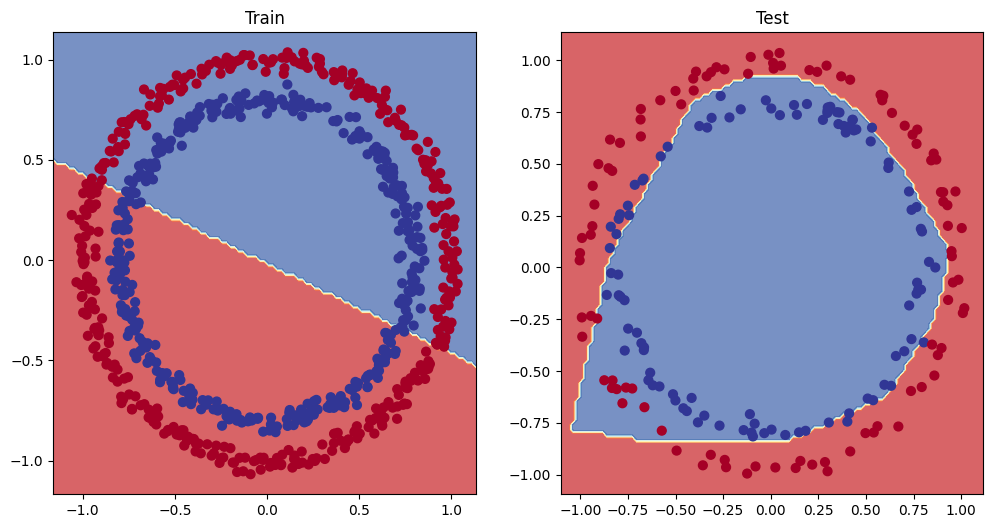

In [69]:
# plot decision boundaries

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train) # model_1 = no non_linearity

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)  # model_3 =has a non-linearity

**Chalange:** Can you impprove model\ to do better than 80% accurach on the test data?

## 7. Replicatin non=linear activation functions
 Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

 And these tools are linear & non-linear functions

In [70]:
# Create a tensor
A =torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

In [71]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

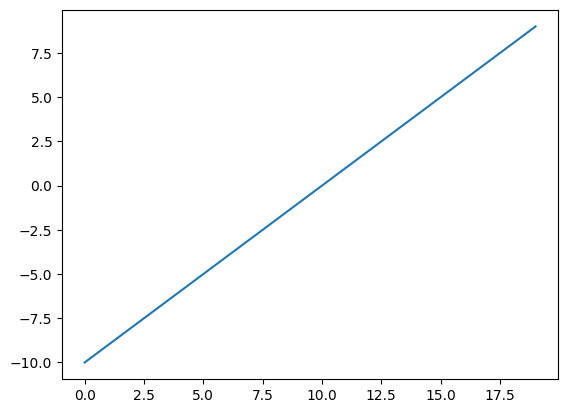

In [72]:
#visualize the tensor
plt.plot(A)

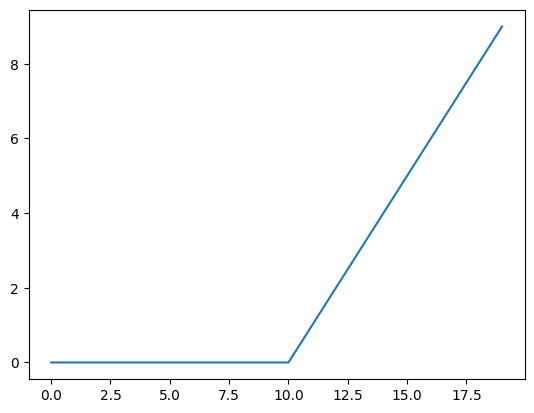

In [73]:
plt.plot(torch.relu(A))

In [74]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0),x) # inputs must be tensors
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

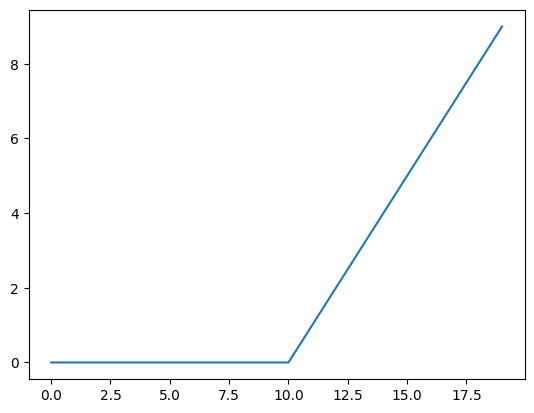

In [75]:
# PLot ReLu activation functions
plt.plot(relu(A))

# Now let's do the same for Sigmoid : https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

In [76]:
def sigmoid(x):
  return 1/(1+torch.exp(-x))

In [77]:
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

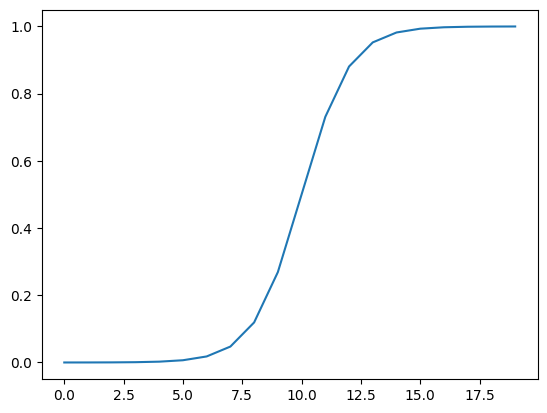

In [78]:
plt.plot(torch.sigmoid(A))

## 8.  putting it all tohether with a multi-class classification problem

* Binary classification = one thing or another (cat vs. dog, spam vs.not spam)

* Multi-class classification =More than one thing or another (cat vs. dog vs chicken)

### 8.1 Creating a toy multi-class dataset

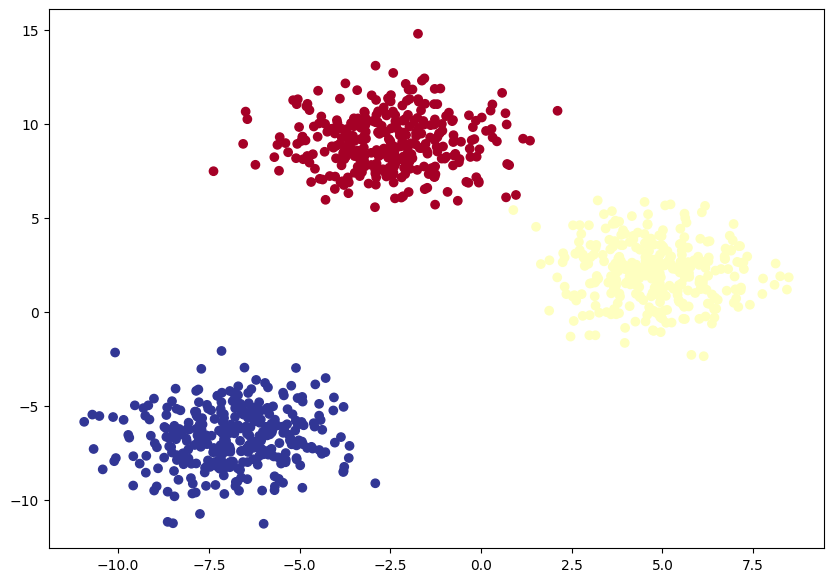

In [79]:
# import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html#sklearn.datasets.make_blobs

from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

# 1. Create multi-class data
X_blob, y_blob= make_blobs(n_samples=1000,
                           n_features=NUM_FEATURES,
                          #  centers=NUM_CLASSES,
                           cluster_std =1.5, # give the clusters a little shake up
                           random_state= RANDOM_SEED
                           )
# 2. Turn data into tensors
X_blob= torch.from_numpy(X_blob).type(torch.float)
y_blob= torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train,X_blob_test, y_blob_train,y_blob_test=train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)


# 4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [80]:
### 8.2 Building a multi-class slassification model in PyTorch
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [81]:
# Build a multi-class slassification model

class BlobModel(nn.Module):
  def __init__(self, input_features, out_features, hidden_units=8):

    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features= input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=out_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device

model_4= BlobModel(input_features=2,
                   out_features=4,
                   hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [82]:
X_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 1, 1, 0]))

In [83]:
torch.unique(y_blob_train)

tensor([0, 1, 2])

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In [84]:
# Create a loss function for multi-class classification

loss_fn=nn.CrossEntropyLoss()

#Create an optimizer for multi-class classification
optimizer= torch.optim.SGD(params=model_4.parameters(),
                           lr=0.1) # learning rate is a hyperparameter you can change

## 8.4 Gettingt prediction probabilities for a multi-class Pytorch model

In order to evaluate and train and test our model, we need to convert our model's outputs(logtis ) to prediction probabilities and then to orediction labels.

Logits(raw o/p of the model) ->Pred_prob(use the softmax) -> Pred Labels(take the argmax of the prediction probabilites)


In [85]:
# let's get some raw outputs of our model(logits)
model_4.eval()
with torch.inference_mode():
  y_logits=model_4(X_blob_test.to(device))

y_logits[:10]

tensor([[-0.5237,  2.3393,  2.6401,  2.1642],
        [ 0.9143, -0.3544, -0.0244, -1.3403],
        [ 0.9735, -0.4166, -0.0660, -1.4409],
        [-0.7948,  0.0490, -0.7677,  0.3211],
        [-0.7592,  1.8848,  1.8249,  1.9368],
        [ 1.0934, -0.0192,  0.5810, -1.1766],
        [-1.1922, -0.4407, -1.7560,  0.1853],
        [-0.4351,  1.9048,  2.1007,  1.7081],
        [-0.6226,  0.2117, -0.4087,  0.3357],
        [-0.5482,  1.8662,  1.9602,  1.7596]], device='cuda:0')

In [86]:
next(model_4.parameters()).device

device(type='cuda', index=0)

In [87]:
X_blob_test.device

device(type='cpu')

In [88]:
# convert our model's logit outputs to prediction probabilities
y_pred_probs=torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.5237,  2.3393,  2.6401,  2.1642],
        [ 0.9143, -0.3544, -0.0244, -1.3403],
        [ 0.9735, -0.4166, -0.0660, -1.4409],
        [-0.7948,  0.0490, -0.7677,  0.3211],
        [-0.7592,  1.8848,  1.8249,  1.9368]], device='cuda:0')
tensor([[0.0176, 0.3079, 0.4160, 0.2585],
        [0.5627, 0.1582, 0.2201, 0.0590],
        [0.5910, 0.1472, 0.2090, 0.0528],
        [0.1351, 0.3140, 0.1388, 0.4122],
        [0.0232, 0.3261, 0.3072, 0.3435]], device='cuda:0')


In [90]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0')

In [89]:
torch.max(y_pred_probs[0])

tensor(0.4160, device='cuda:0')

In [91]:
torch.argmax(y_pred_probs[0])

tensor(2, device='cuda:0')

In [92]:
# convert our model's prediction probabilities to prediction labels
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([2, 0, 0, 3, 3, 0, 3, 2, 3, 2, 2, 3, 2, 2, 2, 0, 0, 3, 0, 0, 0, 2, 2, 3,
        3, 3, 0, 3, 3, 2, 0, 3, 3, 0, 3, 3, 3, 0, 2, 3, 2, 0, 0, 3, 2, 0, 3, 3,
        2, 0, 3, 2, 2, 3, 0, 0, 2, 2, 0, 3, 3, 2, 0, 3, 0, 2, 2, 0, 0, 2, 2, 0,
        0, 0, 3, 0, 0, 0, 0, 3, 2, 0, 0, 3, 0, 0, 3, 0, 0, 3, 0, 0, 1, 0, 0, 0,
        3, 2, 0, 3, 2, 2, 0, 2, 0, 0, 2, 2, 0, 3, 3, 3, 2, 0, 3, 0, 2, 3, 3, 2,
        3, 0, 1, 3, 3, 2, 2, 2, 0, 0, 3, 3, 0, 0, 2, 2, 2, 2, 2, 3, 3, 2, 3, 3,
        0, 0, 2, 0, 0, 0, 3, 2, 0, 3, 2, 3, 0, 0, 3, 3, 3, 2, 0, 3, 2, 0, 0, 2,
        0, 0, 3, 2, 0, 3, 3, 3, 2, 3, 0, 3, 2, 3, 0, 3, 3, 3, 2, 3, 3, 0, 2, 2,
        2, 0, 3, 2, 0, 2, 0, 2], device='cuda:0')

In [93]:
y_blob_test

tensor([0, 2, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1,
        1, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1,
        0, 2, 1, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2,
        1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2,
        1, 2, 0, 1, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1,
        2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0,
        2, 2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 0,
        0, 2, 1, 0, 2, 0, 2, 0])

## 8.5 creating a training loop and testing loop for a multi-class Pytorch model

In [94]:
# fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs= 100

# Put data to the target device
X_blob_train, y_blob_train, =X_blob_train.to(device), y_blob_train.to(device)
X_blob_test,y_blob_test=X_blob_test.to(device), y_blob_test.to(device)

#loop through data
for epoch in range(epochs):
  ## Training
  model_4.train()

  y_logits=model_4(X_blob_train)

  y_pred= torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss=loss_fn(y_logits,y_blob_train)
  acc=accuracy_fn(y_true=y_blob_train,
                  y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing

  model_4.eval()
  with torch.inference_mode():
    test_logits=model_4(X_blob_test)
    test_preds=torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test,
                           y_pred=test_pred)

  # print out what's happens

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | "
              f"Loss: {loss:.4f}, Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 2.0286, Acc: 0.75% | Test Loss: 0.8255, Test Acc: 28.50%
Epoch: 10 | Loss: 0.0772, Acc: 99.88% | Test Loss: 0.0630, Test Acc: 28.50%
Epoch: 20 | Loss: 0.0264, Acc: 99.88% | Test Loss: 0.0232, Test Acc: 28.50%
Epoch: 30 | Loss: 0.0158, Acc: 99.88% | Test Loss: 0.0140, Test Acc: 28.50%
Epoch: 40 | Loss: 0.0115, Acc: 99.88% | Test Loss: 0.0101, Test Acc: 28.50%
Epoch: 50 | Loss: 0.0092, Acc: 99.88% | Test Loss: 0.0079, Test Acc: 28.50%
Epoch: 60 | Loss: 0.0078, Acc: 99.88% | Test Loss: 0.0065, Test Acc: 28.50%
Epoch: 70 | Loss: 0.0068, Acc: 99.88% | Test Loss: 0.0056, Test Acc: 28.50%
Epoch: 80 | Loss: 0.0062, Acc: 99.88% | Test Loss: 0.0049, Test Acc: 28.50%
Epoch: 90 | Loss: 0.0056, Acc: 99.88% | Test Loss: 0.0044, Test Acc: 28.50%


# 8.6 making and evaluating prediction with a Pytorch multi-class model



In [95]:
# Make prediction
model_4.eval()
with torch.inference_mode():
  y_logits=model_4(X_blob_test)


# View the first 10 prediction
y_logits[:10]

tensor([[ 7.1340, -6.1292, -3.6746, -2.5139],
        [ 0.9794, -5.7976,  9.6721,  1.6460],
        [ 0.9258, -5.9823, 10.1779,  1.7725],
        [-3.1818,  5.2144, -3.7054, -0.7310],
        [ 4.4686, -2.5326, -5.0651, -2.3735],
        [ 2.9638, -8.4905, 10.7386,  1.5488],
        [-6.5428, 10.1540, -6.2984, -0.7485],
        [ 5.6533, -5.0138, -2.6143, -2.0113],
        [-1.9289,  3.2766, -2.5387, -0.6781],
        [ 5.1102, -4.0189, -3.4417, -2.1087]], device='cuda:0')

In [96]:
# Go from probs to pred labels
y_pred_soft=torch.softmax(y_pred_probs, dim=1)
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds[:10], y_pred_soft[:10]

(tensor([2, 0, 0, 3, 3, 0, 3, 2, 3, 2], device='cuda:0'),
 tensor([[0.1961, 0.2622, 0.2921, 0.2496],
         [0.3354, 0.2238, 0.2381, 0.2027],
         [0.3439, 0.2206, 0.2347, 0.2008],
         [0.2213, 0.2647, 0.2221, 0.2920],
         [0.1976, 0.2676, 0.2625, 0.2723],
         [0.3142, 0.2258, 0.2579, 0.2021],
         [0.2185, 0.2530, 0.2066, 0.3219],
         [0.1990, 0.2656, 0.2845, 0.2509],
         [0.2229, 0.2675, 0.2305, 0.2791],
         [0.1988, 0.2670, 0.2757, 0.2584]], device='cuda:0'))

In [98]:
y_blob_test

tensor([0, 2, 2, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1,
        1, 1, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1,
        0, 2, 1, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 0, 2, 2, 2,
        1, 0, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1, 2, 0, 0, 1, 2,
        1, 2, 0, 1, 1, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1,
        2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0,
        2, 2, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 0,
        0, 2, 1, 0, 2, 0, 2, 0], device='cuda:0')

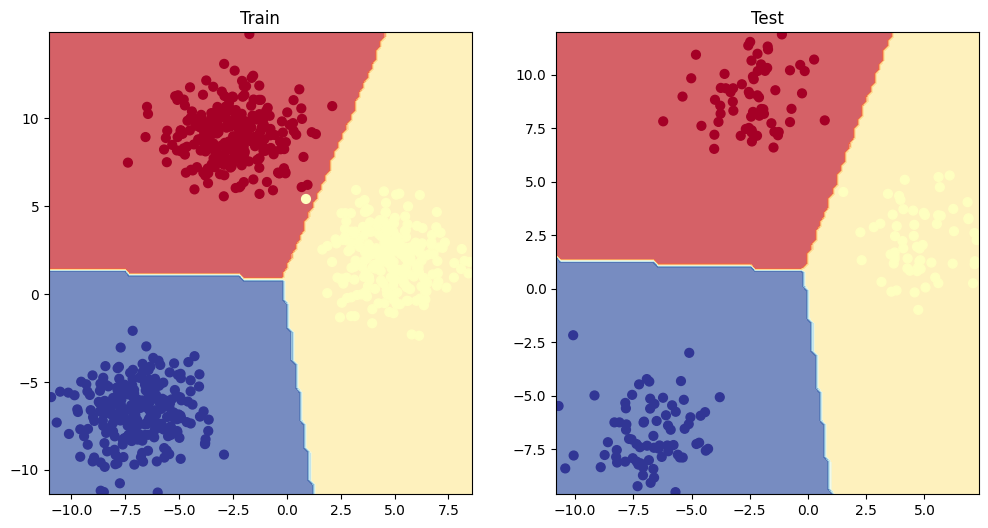

In [97]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,y_blob_test)

## 9. A few more classification metrics... (to evaluate our classification model)

* Accuracy- out of 1-- samples, how many does our model get right ?
* Precision
* Recall
* F1-score
*confusion matrix
* Classification report

In [99]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.1 MB/s eta 0:00:00


In [101]:
from torchmetrics.classification import Accuracy

# Example for binary classification
torchmetric_accuracy = Accuracy(task="binary").to(device)

# Example for multiclass classification (e.g., 10 classes)
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=10).to(device)

# Example for multilabel classification
torchmetric_accuracy = Accuracy(task="multilabel", num_labels=5).to(device)

In [104]:
torchmetric_accuracy

MultilabelAccuracy()

In [103]:
torchmetric_accuracy.device

device(type='cuda', index=0)